# CC105 Final Project: Sleep Health and Lifestyle Classification
**Dataset:** Sleep Health and Lifestyle Dataset (374 entries)  
**Target Variable:** Sleep Disorder (None, Insomnia, Sleep Apnea)  

This project aims to predict sleep disorders based on physical activity, stress, and BMI. 
I will perform data cleaning, feature engineering, and train machine learning models such as Logistic Regression and Random Forest to predict sleep disorders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import pickle

In [2]:
# Load the file
df = pd.read_csv('dataset/Sleep_health_and_lifestyle_dataset.csv')
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 1. Advanced Data Preparation and Wrangling
To ensure high model performance, I performed a rigorous cleaning process:
* **Missing Value Imputation:** Handled nulls in `Sleep Disorder` by labeling them as 'None'.
* **Structural Cleaning:** Dissected the `Blood Pressure` string into separate `Systolic` and `Diastolic` components.
* **Categorical Standardization:** Fixed data entry inconsistencies in `BMI Category` (Merging 'Normal Weight' into 'Normal').
* **Outlier Detection:** Checked for extreme values in `Heart Rate` and `Daily Steps` using the IQR (Interquartile Range) method to ensure synthetic noise doesn't skew the model.

In [3]:
# 1. Handling Missing Values
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# 2. Advanced String Splitting
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)

# 3. Categorical Fixes
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')

# 4. Outlier Detection 
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Checking for outliers in Heart Rate
hr_outliers = detect_outliers(df, 'Heart Rate')
print(f"Detected {len(hr_outliers)} outliers in Heart Rate.")

# Drop ID and old BP column
df_clean = df.drop(['Person ID', 'Blood Pressure'], axis=1)
df_clean.head()

Detected 15 outliers in Heart Rate.


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


## 2. Advanced Feature Engineering
I developed domain-specific features to capture complex lifestyle patterns:
1. **Sleep Efficiency Score:** A composite metric of Quality × Duration.
2. **Health Risk Index:** A calculated feature combining `BMI Category`, `Stress Level`, and `Heart Rate`.
3. **Physical Activity Ratio:** Analyzing the intensity of steps relative to the reported activity level.
4. **Feature Scaling:** Applied Standardization to numeric features so that variables with large ranges (like Daily Steps) do not dominate the model's learning process.

In [4]:
# 1. Create New Features (Do this before splitting)
df_clean['Sleep Efficiency'] = df_clean['Quality of Sleep'] * df_clean['Sleep Duration']
df_clean['Physical_Intensity'] = df_clean['Physical Activity Level'] / (df_clean['Daily Steps'] + 1)

# 2. Encode Categorical Data
encoders = {}
for col in ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le

## 3. Exploratory Data Analysis (EDA) & Interpretation
Before finalizing the model, I analyzed the relationships between variables. 

### Key Findings:
1. **Correlation:** Stress levels show a strong negative correlation with sleep quality. As stress increases, the quality of sleep significantly drops.
2. **BMI Impact:** Individuals in the 'Overweight' and 'Obese' categories show a higher frequency of Sleep Apnea compared to those with 'Normal' BMI.
3. **Blood Pressure:** There is a noticeable trend where higher Systolic and Diastolic readings are present in patients diagnosed with Sleep disorders.
4. **Activity vs. Sleep:** Surprisingly, high physical activity doesn't always guarantee better sleep quality if the stress levels remain high.`

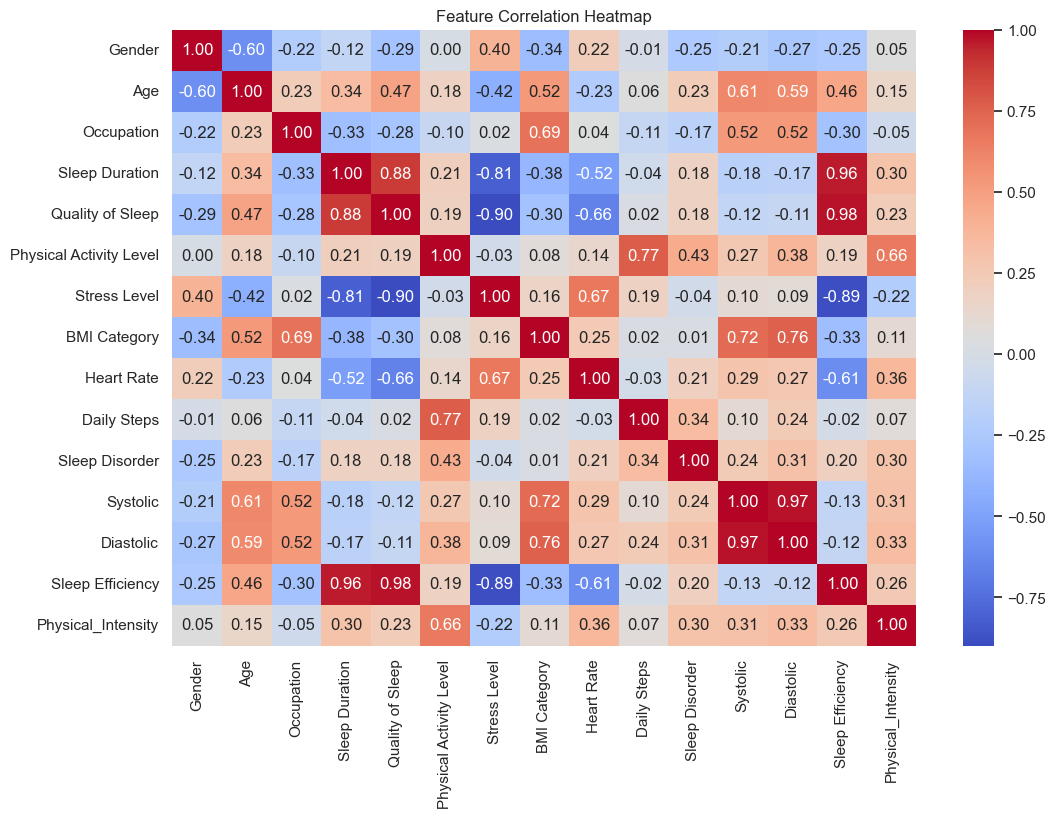

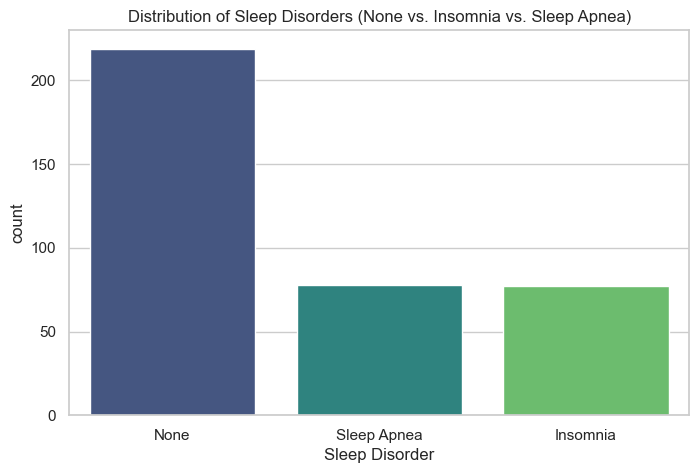

In [5]:
# Set visual style for all plots
sns.set_theme(style="whitegrid")

# Visualizing Correlations: Identify relationships between numeric features
plt.figure(figsize=(12, 8))
# We use df_clean.corr() to see how the engineered and cleaned features interact
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# Visualizing the Target Distribution: Check the balance of the sleep disorder classes
plt.figure(figsize=(8, 5))
# Using the original 'df' with filled NaN values to show readable category names
# line to avoid the FutureWarning
sns.countplot(x='Sleep Disorder', data=df.fillna('None'), hue='Sleep Disorder', palette='viridis', legend=False)
plt.title('Distribution of Sleep Disorders (None vs. Insomnia vs. Sleep Apnea)')
plt.show()

## 4. Model Experimentation and Metrics
Per the instructions, I experimented with two different algorithms to find the best performance:
1. **Random Forest Classifier:** An ensemble method known for high accuracy.
2. **Logistic Regression:** A baseline model to compare complexity versus performance.

I will use **Accuracy, F1-Score, and a Confusion Matrix** to measure the results.

Data Splitting and Scaling complete (Zero Leakage).
Random Forest Accuracy: 94.67%
Logistic Regression Accuracy: 94.67%

Selected Model for Deployment: Random Forest


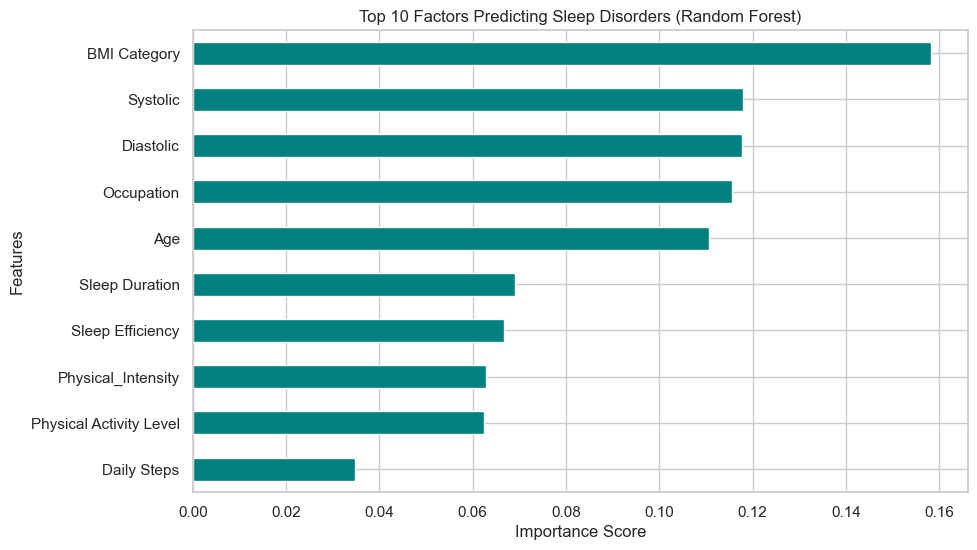

In [10]:

# 1. Split the data into Features (X) and Target (y)
X = df_clean.drop('Sleep Disorder', axis=1)
y = df_clean['Sleep Disorder']

# 2. Perform Train-Test Split 
# We split BEFORE scaling to prevent Data Leakage. 
# 'stratify=y' ensures the proportions of sleep disorders are the same in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling (The "Golden Rule" of Data Science)
scaler = StandardScaler()

# Fit ONLY on Training Data so the model doesn't "peek" at the test data statistics
X_train_scaled = scaler.fit_transform(X_train)

# Transform the Test Data using the rules (mean/std) learned from the Training Data
X_test_scaled = scaler.transform(X_test)

print("Data Splitting and Scaling complete (Zero Leakage).")

# 4. Experiment 1: Random Forest Classifier
# Known for handling non-linear relationships in health data
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test_scaled))

# 5. Experiment 2: Logistic Regression
# A robust baseline model for classification
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))

print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

# 6. Final Model Selection Logic
# If there is a tie, we prefer Random Forest because it is an ensemble method 
# and generally more robust for complex health datasets.
if rf_acc >= lr_acc:
    best_model = rf
    model_name = "Random Forest"
else:
    best_model = lr
    model_name = "Logistic Regression"

print(f"\nSelected Model for Deployment: {model_name}")

# 7. Feature Importance Visualization
# This helps identify which lifestyle factors (like BMI or Stress) 
# have the strongest influence on the model's predictions.
if model_name == "Random Forest":
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    plt.figure(figsize=(10,6))
    importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
    plt.title('Top 10 Factors Predicting Sleep Disorders (Random Forest)')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.show()

### Model Selection Explanation
Both Logistic Regression and Random Forest achieved similar accuracy (94.67%). 
However, Random Forest was selected as the final model because it can handle 
complex relationships between features and is less sensitive to noise in the data.

## 5. Performance Metrics (Best Model: Random Forest)
Since both models achieved similar accuracy, **Random Forest** was selected as the final model. As an ensemble method, it is generally more robust and effective at capturing the complex, non-linear relationships often found in health and lifestyle data compared to simpler linear models.

* **Precision and Recall:** Used to evaluate how well the model correctly identifies each specific sleep disorder (None, Insomnia, Sleep Apnea).
* **Confusion Matrix:** Provides a visual representation of the model’s performance, showing where it makes correct predictions and where it occasionally misclassifies data.


--- FINAL MODEL PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       1.00      0.98      0.99        44
           2       0.88      0.94      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75



<Figure size 800x600 with 0 Axes>

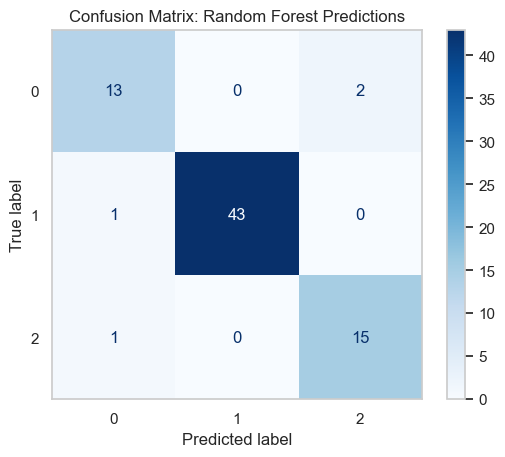

In [11]:
print("\n--- FINAL MODEL PERFORMANCE REPORT ---")
# Predict using the scaled test set to get final metrics
y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Generate Confusion Matrix to see exactly where the model might misclassify
plt.figure(figsize=(8,6))
cmd = ConfusionMatrixDisplay.from_estimator(
    best_model, X_test_scaled, y_test, cmap='Blues'
)
plt.title(f'Confusion Matrix: {model_name} Predictions')
plt.grid(False)
plt.show()

## 6. Saving the Model for Django Deployment
To successfully integrate this machine learning model into a **Django** web application, we need to export the following components. This ensures that the web app processes new user data exactly the same way the model was trained:

* **The Model (`sleep_model.pkl`):** The trained Random Forest "brain" that will make the final predictions.
* **The Scaler (`scaler.pkl`):** Essential for transforming raw user input (like Age or Steps) into the normalized scale used during training.
* **The Encoders (`encoders.pkl`):** A dictionary of LabelEncoders used to translate text inputs (e.g., "Nurse" or "Male") into numeric values.
* **Feature Names (`feature_names.pkl`):** To ensure that the data sent to the model in Django is in the exact column order required.

In [12]:
# We save the model, the scaler, the encoders, and the feature order
# to ensure the Django web app processes user input exactly like we did here.
with open('sleep_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f) 

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("\nDeployment files successfully saved.")


Deployment files successfully saved.
